# Pre-RA Flow PM1: Cell type level subclustering

## Setup

In [1]:
import scyan as sy
import os
import glob
import anndata
import re
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import scanpy as sc
import scanpy.external as sce

print(sy.__version__)
print(anndata.__version__)


/home/jupyter/envs/libs/scyan/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Global seed set to 0


1.5.1
0.10.6


In [2]:
#### ==== parameter set up ==== ####
# define the working path
panel = "PM1"
# define cell types to subset
cell_types = ["total_myeloid_cells"]
data_path='/home/jupyter/projects/pre-ra/flow/raw-data/' + panel + '/labelled-expr/cache/'
fig_path = '/home/jupyter/projects/pre-ra/flow/02-clustering/results/' + panel + '_celltype_subsample'  + "/"
proj_name = 'pre-ra_flow_clustering_' + panel
output_path = '/home/jupyter/projects/pre-ra/flow/02-clustering/data/' +panel + '/'

if not os.path.exists(fig_path): os.makedirs(fig_path)
    
if not os.path.exists(output_path): os.makedirs(output_path)

# define scanpy verbose levels
sc.settings.verbosity = 3
sc.settings.figdir = fig_path
sc.settings.n_jobs = -1

## Functions

In [3]:
def subset_anndata_by_cell_types(anndata_obj, cell_types):
    """
    Subset Anndata object by specific cell types from the metadata column "labels".

    Parameters:
        anndata_obj (anndata.AnnData): Anndata object containing single-cell genomics data.
        cell_types (list): List of cell types to subset.

    Returns:
        dict: Dictionary containing cell types as keys and corresponding Anndata objects as values.
    """
    split_anndata = {}
    for cell_type in cell_types:
        subset_indices = anndata_obj.obs['l1_labels'] == cell_type
        subset_anndata = anndata_obj[subset_indices].copy()
        split_anndata[cell_type] = subset_anndata
    return split_anndata

In [4]:
def subsample_adata_by_group(anndata_obj, target_cells,cluster_key ):
    """
    Subsample Anndata object by specific groupings from the metadata columns by fix target cells.

    Parameters:
        anndata_obj (anndata.AnnData): Anndata object containing single-cell genomics data.
        cluster_key (list): List of cell groupings from metadata
        target_cells (num): an integer of the fixed targeted number of cells per groupings

    Returns:
        Anndata object
    """
    total_cells = len(anndata_obj)
    if total_cells < 5000000:  # Check if total cells is less than 5 million
        print("Total cells less than 5 million. No downsampling performed.")
        return anndata_obj  # Return the original Anndata object
    
    grouped = anndata_obj.obs.groupby(cluster_key)

    downsampled_indices = []
    for _, group in grouped:
        if len(group) > target_cells:
            downsampled_indices.extend(group.sample(target_cells).index)
        else:
            downsampled_indices.extend(group.index)
        
    adata_downsampled = adata_sub_celltype[downsampled_indices]
    return(adata_downsampled)

In [5]:
def save_anndata_list(anndata_list, filenames):
    """
    Save a list of Anndata objects to separate H5AD files.

    Parameters:
        anndata_list (list): List of Anndata objects to be saved.
        filenames (list): List of filenames to save Anndata objects.

    Returns:
        None
    """
    # zip() combines two lists into a single tuple
    for anndata_obj, filename in zip(adata_downsampled_celltypes, filenames):
        print(adata_downsampled_celltypes[anndata_obj])
        adata_downsampled_celltypes[anndata_obj].write_h5ad(filename)

In [6]:
def read_anndata_files(file_tuples):
    """
    Read Anndata objects from H5AD files and store them in a dictionary with custom names.

    Parameters:
        file_tuples (list of tuples): List of tuples where each tuple contains filename and desired name.

    Returns:
        dict: Dictionary containing Anndata objects with custom names.
    """
    anndata_dict = {}
    for filename, name in file_tuples:
        anndata_obj = anndata.read_h5ad(filename)
        anndata_dict[name] = anndata_obj
    return anndata_dict

## Read in data 

In [7]:
print("READING IN ADATA")
adata_file = output_path + "adata_preprocess_unscaled_" + panel + ".h5ad"
print(adata_file)
adata = sc.read_h5ad(adata_file)
print(adata)

READING IN ADATA
/home/jupyter/projects/pre-ra/flow/02-clustering/data/PM1/adata_preprocess_unscaled_PM1.h5ad
AnnData object with n_obs × n_vars = 48067994 × 25
    obs: 'Unnamed: 0', 'sample_id', 'cell_id', 'barcode', 'Time', 'SSC-W', 'SSC-H', 'SSC-A', 'FSC-W', 'FSC-H', 'FSC-A', 'SSC-B-W', 'SSC-B-H', 'SSC-B-A', 'Viability_logicle', 'labels', 'batch', 'panel', 'l1_labels'


In [8]:
cell_labels_to_subset_list = adata.obs['l1_labels'].unique()
print(cell_labels_to_subset_list)

['total_myeloid_cells', 't_cells', 'b_cells', 'total_nk_cells', 'unknown', 'debris', NaN]
Categories (6, object): ['b_cells', 'debris', 't_cells', 'total_myeloid_cells', 'total_nk_cells', 'unknown']


In [9]:
print(pd.crosstab(adata.obs['sample_id'], adata.obs['l1_labels'], margins=True)) 


l1_labels   b_cells  debris   t_cells  total_myeloid_cells  total_nk_cells  \
sample_id                                                                    
PB00052-02    16974    3233     91349                 9793           33528   
PB00055-02    42577    5958    127848                20568           16223   
PB00056-02    31663    5508    142873                51889           38366   
PB00057-02    21286    1902     96178                26512           21201   
PB00058-03     8676    1645     81000                66317           17716   
...             ...     ...       ...                  ...             ...   
PB04671-00    48928    4490    197980                73278           44334   
PB04906-00    67206    7234    206888                32714           62264   
PB04933-00    64514   18266    156946                46208           17110   
PB04937-00    42130   11582    245886                20296          117280   
All         3651074  766585  18784829              7190687      

In [10]:
print(pd.crosstab(adata.obs['l1_labels'], adata.obs['panel'], margins=True)) 


panel                     PM1       All
l1_labels                              
b_cells               3651074   3651074
debris                 766585    766585
t_cells              18784829  18784829
total_myeloid_cells   7190687   7190687
total_nk_cells        4762916   4762916
unknown              12911902  12911902
All                  48067993  48067993


In [11]:
### read in metadata 
meta = pd.read_csv("/home/jupyter/projects/pre-ra/flow/raw-data/2023-11-22_ALTRA_Metadata_labs_long-model-vars.csv")

In [12]:
meta["sample.sampleKitGuid"]

0      KT00052
1      KT00055
2      KT00056
3      KT00057
4      KT00058
        ...   
152    KT04924
153    KT04933
154    KT04937
155    KT02968
156    KT04906
Name: sample.sampleKitGuid, Length: 157, dtype: object

In [13]:
meta = meta[[ 'sample.sampleKitGuid','Status_Xsec','Status_Long', 'subject.biologicalSex', 'subject.subjectGuid', 'days_to_conversion', 'age_conv','bmi_conv','Age2023']]

In [14]:
meta.head()

,sample.sampleKitGuid,Status_Xsec,Status_Long,subject.biologicalSex,subject.subjectGuid,days_to_conversion,age_conv,bmi_conv,Age2023
0,KT00052,at_risk,pre,Female,CU1009,-714.0,58.0,25.648918,60
1,KT00055,early_RA,NaN,Female,CU1008,NaN,NaN,NaN,57
2,KT00056,at_risk,pre,Female,CU1007,-632.0,44.0,26.194977,46
3,KT00057,at_risk,pre,Female,CU1003,-615.0,23.0,23.143062,25
4,KT00058,at_risk,NaN,Female,CU1002,NaN,NaN,NaN,82


In [15]:
### add sample.sampleKitGuid to column metadata of anndata before merging metadata
sample_id = adata.obs["sample_id"]

sliced_ids = [ids[2:7] for ids in sample_id]
sampleKitGuid = ["KT" + ids for ids in sliced_ids]

In [16]:
adata.obs["sample.sampleKitGuid"] = sampleKitGuid

In [17]:
adata.obs[["sample.sampleKitGuid", "sample_id"]].head()

,sample.sampleKitGuid,sample_id
0-0,KT00416,PB00416-01
1-0,KT00416,PB00416-01
2-0,KT00416,PB00416-01
3-0,KT00416,PB00416-01
4-0,KT00416,PB00416-01


In [18]:
### merge meta info back to adata obj
adata.obs = pd.merge(adata.obs, meta, on='sample.sampleKitGuid', how='inner')


In [19]:
adata.obs.head()

,Unnamed: 0,sample_id,cell_id,barcode,Time,SSC-W,SSC-H,SSC-A,FSC-W,FSC-H,...,l1_labels,sample.sampleKitGuid,Status_Xsec,Status_Long,subject.biologicalSex,subject.subjectGuid,days_to_conversion,age_conv,bmi_conv,Age2023
0,0,PB00416-01,3,3aa8470e1eba11ed80481eb6e448aef3,0.0,799684.3125,929036.0,1.238226e+06,793994.2500,1283562.0,...,total_myeloid_cells,KT00416,NaN,pre,Female,CU1009,-352.0,58.0,25.648918,60
1,1,PB00416-01,4,3aa847221eba11ed80481eb6e448aef3,12.0,667461.0625,406061.0,4.517165e+05,704542.6875,945775.0,...,t_cells,KT00416,NaN,pre,Female,CU1009,-352.0,58.0,25.648918,60
2,2,PB00416-01,5,3aa847401eba11ed80481eb6e448aef3,12.0,687574.5625,361755.0,4.145559e+05,681714.7500,939086.0,...,t_cells,KT00416,NaN,pre,Female,CU1009,-352.0,58.0,25.648918,60
3,3,PB00416-01,6,3aa8475e1eba11ed80481eb6e448aef3,18.0,661792.3125,479074.0,5.284125e+05,738961.9375,688436.0,...,b_cells,KT00416,NaN,pre,Female,CU1009,-352.0,58.0,25.648918,60
4,4,PB00416-01,7,3aa847721eba11ed80481eb6e448aef3,34.0,631029.5000,739303.0,7.775367e+05,702856.1875,1086428.0,...,total_nk_cells,KT00416,NaN,pre,Female,CU1009,-352.0,58.0,25.648918,60


In [20]:
adata.obs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48067994 entries, 0 to 48067993
Data columns (total 28 columns):
 #   Column                 Dtype   
---  ------                 -----   
 0   Unnamed: 0             int64   
 1   sample_id              category
 2   cell_id                int64   
 3   barcode                object  
 4   Time                   float64 
 5   SSC-W                  float64 
 6   SSC-H                  float64 
 7   SSC-A                  float64 
 8   FSC-W                  float64 
 9   FSC-H                  float64 
 10  FSC-A                  float64 
 11  SSC-B-W                float64 
 12  SSC-B-H                float64 
 13  SSC-B-A                float64 
 14  Viability_logicle      float64 
 15  labels                 category
 16  batch                  category
 17  panel                  category
 18  l1_labels              category
 19  sample.sampleKitGuid   object  
 20  Status_Xsec            object  
 21  Status_Long            object

## Subset by sample selection 

In [ ]:
meta[meta['days_to_conversion'] <= -750]

In [21]:
len(meta['sample.sampleKitGuid'].unique())

157

In [22]:
len(adata.obs['sample.sampleKitGuid'].unique())

134

In [23]:
samples_to_remove = meta[meta['days_to_conversion'] <= -750]["sample.sampleKitGuid"]

In [24]:
len(samples_to_remove)

6

In [25]:
# Convert the column to string type if it's not already
adata.obs['sample.sampleKitGuid'] = adata.obs['sample.sampleKitGuid'].astype(str)

In [26]:
# Define the condition based on the metadata in the "obs" slot
condition = ~adata.obs['sample.sampleKitGuid'].isin(samples_to_remove)


In [27]:
# Use boolean indexing with the negation operator (~) to remove samples that meet the condition
adata_sub = adata[condition]

In [28]:
# check if samples to remove is still in filtered adata
adata_sub.obs['sample.sampleKitGuid'].isin(samples_to_remove).any()

False

In [29]:
len(adata_sub.obs['sample.sampleKitGuid'].unique())

128

In [30]:
adata_sub.write_h5ad(output_path + "adata_preprocess_unscaled_sample_select_sub_" + panel + ".h5ad")

In [31]:
adata_sub

AnnData object with n_obs × n_vars = 46236985 × 25
    obs: 'Unnamed: 0', 'sample_id', 'cell_id', 'barcode', 'Time', 'SSC-W', 'SSC-H', 'SSC-A', 'FSC-W', 'FSC-H', 'FSC-A', 'SSC-B-W', 'SSC-B-H', 'SSC-B-A', 'Viability_logicle', 'labels', 'batch', 'panel', 'l1_labels', 'sample.sampleKitGuid', 'Status_Xsec', 'Status_Long', 'subject.biologicalSex', 'subject.subjectGuid', 'days_to_conversion', 'age_conv', 'bmi_conv', 'Age2023'

In [32]:
print(pd.crosstab(adata_sub.obs['l1_labels'], adata_sub.obs['panel'], margins=True)) 


panel                     PM1       All
l1_labels                              
b_cells               3525529   3525529
debris                 728132    728132
t_cells              18104954  18104954
total_myeloid_cells   6811149   6811149
total_nk_cells        4544043   4544043
unknown              12523177  12523177
All                  46236984  46236984


In [33]:
cellcount_sampleselect = pd.crosstab(adata_sub.obs['sample_id'], adata_sub.obs['l1_labels'], margins=True)

cellcount_sampleselect.reset_index().rename_axis(None, axis=1)

cellcount_sampleselect = cellcount_sampleselect.add_prefix("sample_select_")

In [34]:
cellcount_sampleselect

l1_labels,sample_select_b_cells,sample_select_debris,sample_select_t_cells,sample_select_total_myeloid_cells,sample_select_total_nk_cells,sample_select_unknown,sample_select_All
sample_id,,,,,,,
PB00052-02,16974,3233,91349,9793,33528,80029,234906
PB00055-02,42577,5958,127848,20568,16223,107787,320961
PB00056-02,31663,5508,142873,51889,38366,101450,371749
PB00057-02,21286,1902,96178,26512,21201,77424,244503
PB00058-03,8676,1645,81000,66317,17716,38297,213651
...,...,...,...,...,...,...,...
PB04671-00,48928,4490,197980,73278,44334,141736,510746
PB04906-00,67206,7234,206888,32714,62264,171430,547736
PB04933-00,64514,18266,156946,46208,17110,84654,387698


## Subset Cell Types 

### Sample composition in cell types

In [35]:
adata_sub_celltype = adata_sub[adata_sub.obs['l1_labels'].isin(cell_types)]

In [36]:
adata_sub_celltype

View of AnnData object with n_obs × n_vars = 6811149 × 25
    obs: 'Unnamed: 0', 'sample_id', 'cell_id', 'barcode', 'Time', 'SSC-W', 'SSC-H', 'SSC-A', 'FSC-W', 'FSC-H', 'FSC-A', 'SSC-B-W', 'SSC-B-H', 'SSC-B-A', 'Viability_logicle', 'labels', 'batch', 'panel', 'l1_labels', 'sample.sampleKitGuid', 'Status_Xsec', 'Status_Long', 'subject.biologicalSex', 'subject.subjectGuid', 'days_to_conversion', 'age_conv', 'bmi_conv', 'Age2023'

In [37]:
meta_adata_type_sub = adata_sub.obs[adata_sub.obs['l1_labels'].isin(cell_types)]

In [38]:
pd.crosstab(meta_adata_type_sub['sample_id'], meta_adata_type_sub['l1_labels'], margins=True)


l1_labels,total_myeloid_cells,All
sample_id,,
PB00052-02,9793,9793
PB00055-02,20568,20568
PB00056-02,51889,51889
PB00057-02,26512,26512
PB00058-03,66317,66317
...,...,...
PB04671-00,73278,73278
PB04906-00,32714,32714
PB04933-00,46208,46208


In [39]:
celltype_counts = pd.crosstab(meta_adata_type_sub['sample_id'], meta_adata_type_sub['l1_labels'], margins=True)

celltype_counts.reset_index().rename_axis(None, axis=1)

,sample_id,total_myeloid_cells,All
0,PB00052-02,9793,9793
1,PB00055-02,20568,20568
2,PB00056-02,51889,51889
3,PB00057-02,26512,26512
4,PB00058-03,66317,66317
...,...,...,...
124,PB04671-00,73278,73278
125,PB04906-00,32714,32714
126,PB04933-00,46208,46208
127,PB04937-00,20296,20296


In [40]:
celltype_counts.describe()

l1_labels,total_myeloid_cells,All
count,1.290000e+02,1.290000e+02
mean,1.055992e+05,1.055992e+05
std,5.962322e+05,5.962322e+05
min,2.293000e+03,2.293000e+03
25%,2.583500e+04,2.583500e+04
50%,4.578200e+04,4.578200e+04
75%,6.774900e+04,6.774900e+04
max,6.811149e+06,6.811149e+06


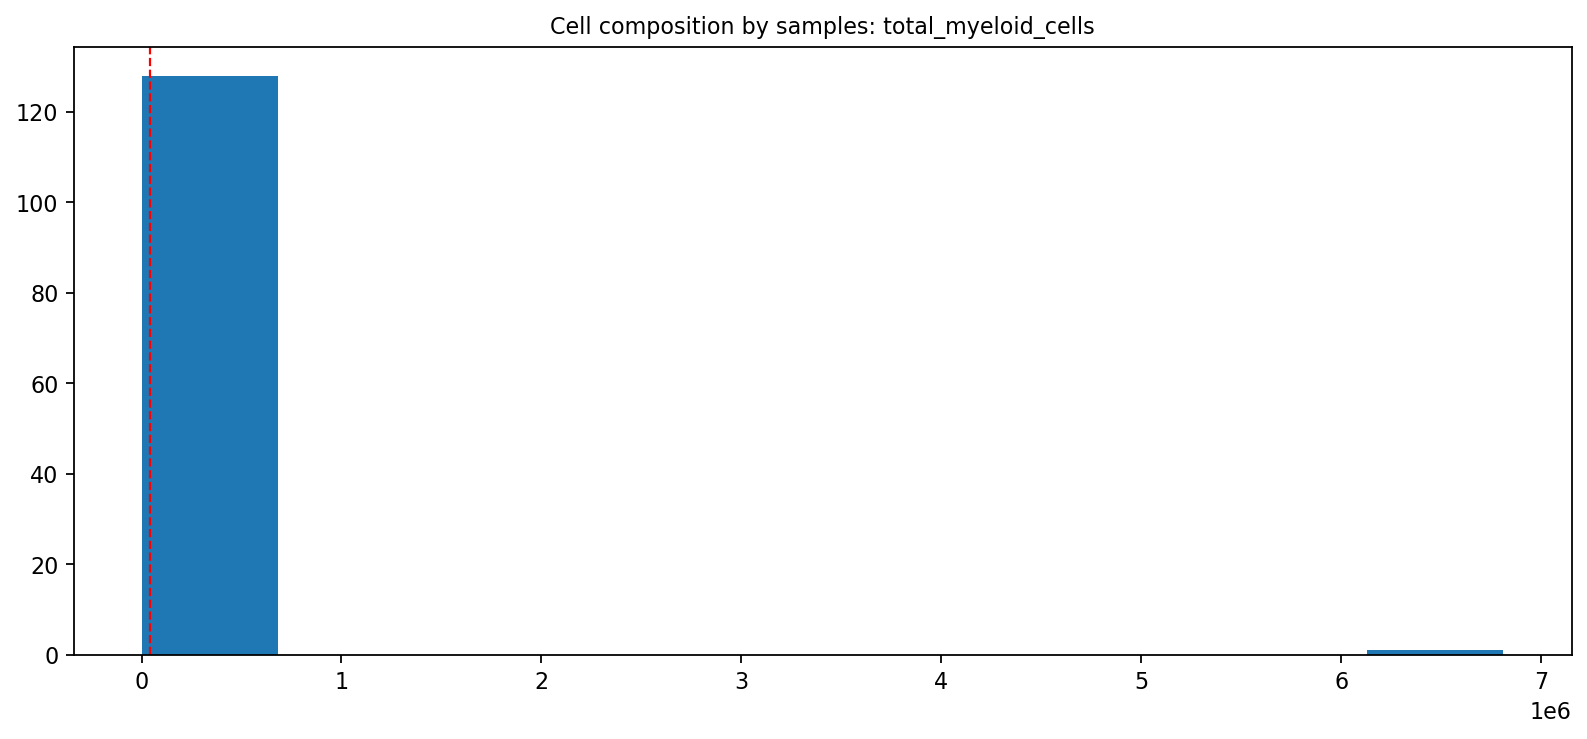

In [ ]:
for ct in cell_types:
    plt.figure(figsize=(12, 5))
    plt.title("Cell composition by samples: " + ct)
    plt.hist(celltype_counts[[ct]])
    plt.axvline(40000, color='red', linestyle='dashed', linewidth=1)

### Conditional cell type subsampling

In [ ]:
adata_downsampled = subsample_adata_by_group(adata_sub_celltype, target_cells = 40000,cluster_key= ["sample_id", "l1_labels"] )

/tmp/ipykernel_45450/937687182.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = anndata_obj.obs.groupby(cluster_key)


In [ ]:
adata_downsampled

View of AnnData object with n_obs × n_vars = 4192099 × 25
    obs: 'Unnamed: 0', 'sample_id', 'cell_id', 'barcode', 'Time', 'SSC-W', 'SSC-H', 'SSC-A', 'FSC-W', 'FSC-H', 'FSC-A', 'SSC-B-W', 'SSC-B-H', 'SSC-B-A', 'Viability_logicle', 'labels', 'batch', 'panel', 'l1_labels', 'sample.sampleKitGuid', 'Status_Xsec', 'Status_Long', 'subject.biologicalSex', 'subject.subjectGuid', 'days_to_conversion', 'age_conv', 'bmi_conv', 'Age2023'

In [ ]:
celltype_counts_downsample =pd.crosstab(adata_downsampled.obs['sample_id'], adata_downsampled.obs["l1_labels"],margins=True)

In [ ]:
celltype_counts_downsample.reset_index().rename_axis(None, axis=1)

,sample_id,total_myeloid_cells,All
0,PB00052-02,9793,9793
1,PB00055-02,20568,20568
2,PB00056-02,40000,40000
3,PB00057-02,26512,26512
4,PB00058-03,40000,40000
...,...,...,...
124,PB04671-00,40000,40000
125,PB04906-00,32714,32714
126,PB04933-00,40000,40000
127,PB04937-00,20296,20296


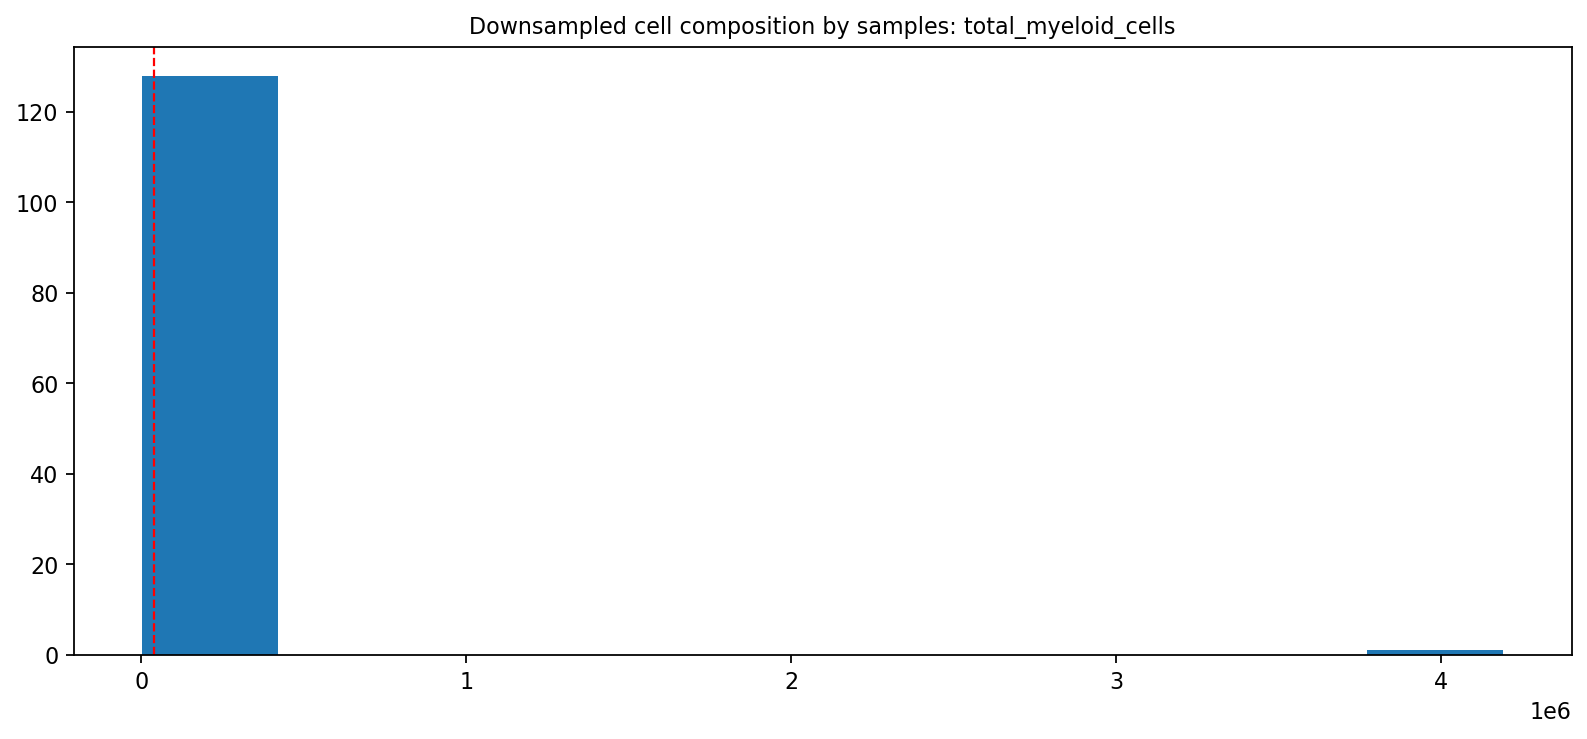

In [ ]:
for ct in cell_types:
    plt.figure(figsize=(12, 5))
    plt.title("Downsampled cell composition by samples: " + ct)
    plt.hist(celltype_counts_downsample[[ct]])
    plt.axvline(40000, color='red', linestyle='dashed', linewidth=1)

In [ ]:
celltype_counts_downsample = celltype_counts_downsample.add_prefix("downsample_")

In [ ]:
adata_downsampled_celltypes = subset_anndata_by_cell_types(adata_downsampled,cell_types)

In [ ]:
adata_downsampled_celltypes

{'total_myeloid_cells': AnnData object with n_obs × n_vars = 4192099 × 25
     obs: 'Unnamed: 0', 'sample_id', 'cell_id', 'barcode', 'Time', 'SSC-W', 'SSC-H', 'SSC-A', 'FSC-W', 'FSC-H', 'FSC-A', 'SSC-B-W', 'SSC-B-H', 'SSC-B-A', 'Viability_logicle', 'labels', 'batch', 'panel', 'l1_labels', 'sample.sampleKitGuid', 'Status_Xsec', 'Status_Long', 'subject.biologicalSex', 'subject.subjectGuid', 'days_to_conversion', 'age_conv', 'bmi_conv', 'Age2023'}

In [ ]:
filenames = [output_path + "adata_preprocess_unscaled_downsmpl_celltypes_" + cell_type + "_" + panel + ".h5ad" for cell_type in cell_types]

In [ ]:
save_anndata_list(adata_downsampled_celltypes, filenames)

AnnData object with n_obs × n_vars = 4192099 × 25
    obs: 'Unnamed: 0', 'sample_id', 'cell_id', 'barcode', 'Time', 'SSC-W', 'SSC-H', 'SSC-A', 'FSC-W', 'FSC-H', 'FSC-A', 'SSC-B-W', 'SSC-B-H', 'SSC-B-A', 'Viability_logicle', 'labels', 'batch', 'panel', 'l1_labels', 'sample.sampleKitGuid', 'Status_Xsec', 'Status_Long', 'subject.biologicalSex', 'subject.subjectGuid', 'days_to_conversion', 'age_conv', 'bmi_conv', 'Age2023'


In [ ]:
file_tups = list(zip(filenames, cell_types))
file_tups

[('/home/jupyter/projects/pre-ra/flow/02-clustering/data/PM1/adata_preprocess_unscaled_downsmpl_celltypes_total_myeloid_cells_PM1.h5ad',
  'total_myeloid_cells')]

In [ ]:
### check anndata after exporting

adata_downsampled_celltypes = read_anndata_files(file_tups)
adata_downsampled_celltypes

{'total_myeloid_cells': AnnData object with n_obs × n_vars = 4192099 × 25
     obs: 'Unnamed: 0', 'sample_id', 'cell_id', 'barcode', 'Time', 'SSC-W', 'SSC-H', 'SSC-A', 'FSC-W', 'FSC-H', 'FSC-A', 'SSC-B-W', 'SSC-B-H', 'SSC-B-A', 'Viability_logicle', 'labels', 'batch', 'panel', 'l1_labels', 'sample.sampleKitGuid', 'Status_Xsec', 'Status_Long', 'subject.biologicalSex', 'subject.subjectGuid', 'days_to_conversion', 'age_conv', 'bmi_conv', 'Age2023'}

## Cell Frequency Tables

In [ ]:
cellcount_sampleselect.reset_index(inplace=True)

In [ ]:
celltype_counts_downsample.reset_index(inplace=True)

In [ ]:
### merge total counts (after sample selection) to 
cellcounts_df = pd.merge(cellcount_sampleselect, celltype_counts_downsample)

In [ ]:
cellcounts_df

l1_labels,sample_id,sample_select_b_cells,sample_select_debris,sample_select_t_cells,sample_select_total_myeloid_cells,sample_select_total_nk_cells,sample_select_unknown,sample_select_All,downsample_total_myeloid_cells,downsample_All
0,PB00052-02,16974,3233,91349,9793,33528,80029,234906,9793,9793
1,PB00055-02,42577,5958,127848,20568,16223,107787,320961,20568,20568
2,PB00056-02,31663,5508,142873,51889,38366,101450,371749,40000,40000
3,PB00057-02,21286,1902,96178,26512,21201,77424,244503,26512,26512
4,PB00058-03,8676,1645,81000,66317,17716,38297,213651,40000,40000
...,...,...,...,...,...,...,...,...,...,...
124,PB04671-00,48928,4490,197980,73278,44334,141736,510746,40000,40000
125,PB04906-00,67206,7234,206888,32714,62264,171430,547736,32714,32714
126,PB04933-00,64514,18266,156946,46208,17110,84654,387698,40000,40000
127,PB04937-00,42130,11582,245886,20296,117280,163536,600710,20296,20296


In [ ]:
cellcounts_df.to_csv(output_path + "counts_freq_celltypes_sample_select_" + panel + ".csv")